### Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

C:\Users\LEGION\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Importing and Checking Data

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [4]:
test_ids = test['id']

In [3]:
print(f'Training Data Shape: {train.shape}')
print(f'Test Data Shape: {test.shape}')

Training Data Shape: (439140, 16)
Test Data Shape: (188165, 15)


In [4]:
print(train.isnull().sum())
print(test.isnull().sum())

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64
id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
dtype: int64


In [257]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  str    
 2   Compound                439140 non-null  str    
 3   Race                    439140 non-null  str    
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change         439140 

In [258]:
train.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [259]:
train.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


### EDA

0         1.0
1         0.0
2         1.0
3         0.0
4         0.0
         ... 
439135    0.0
439136    0.0
439137    0.0
439138    0.0
439139    0.0
Name: PitNextLap, Length: 439140, dtype: float64


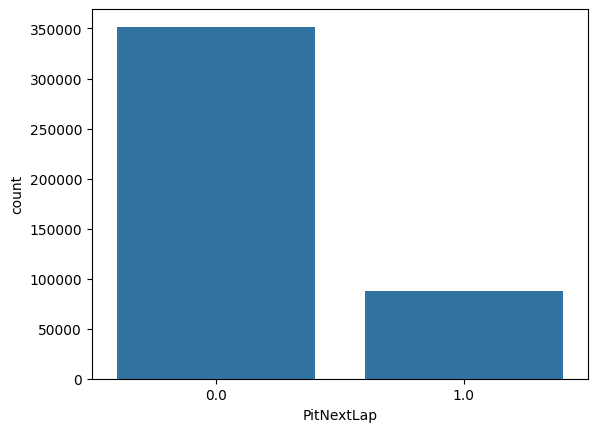

In [143]:
print(train['PitNextLap'])
sns.countplot(x=train['PitNextLap'], data=train)
plt.show()

C:\Users\LEGION\AppData\Local\Temp\ipykernel_13572\2193448116.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in train.select_dtypes(include='object').columns:


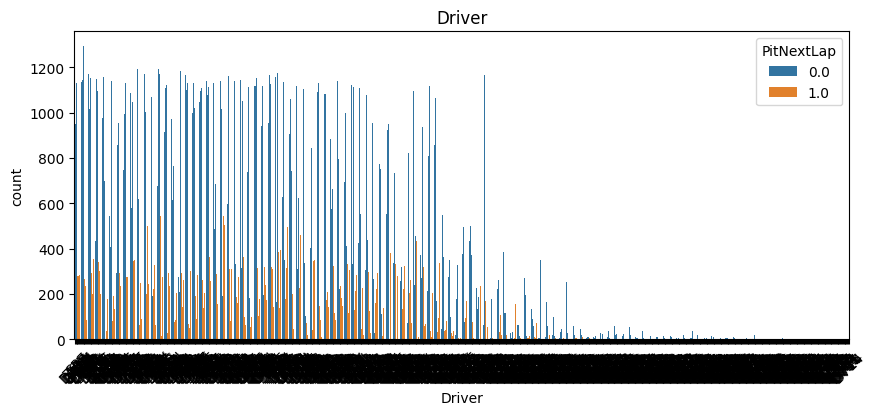

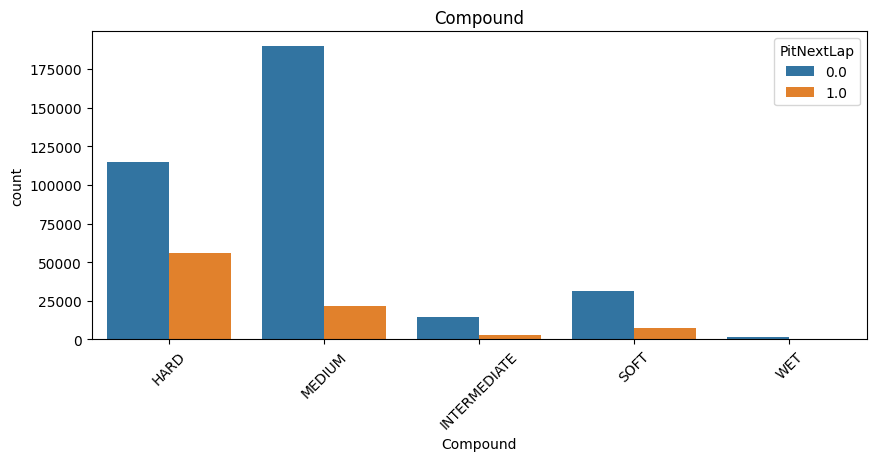

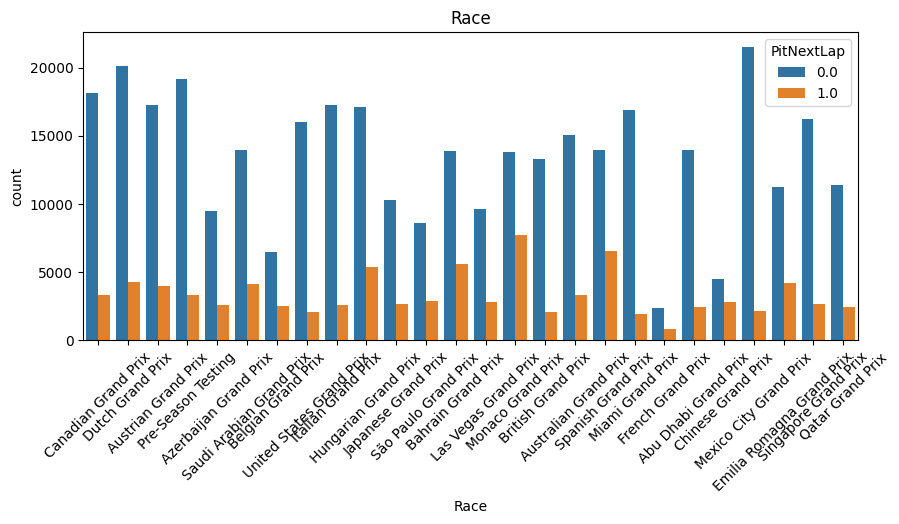

In [144]:
for col in train.select_dtypes(include='object').columns:
    plt.figure(figsize=(10,4))
    sns.countplot(x=col, hue='PitNextLap', data=train)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

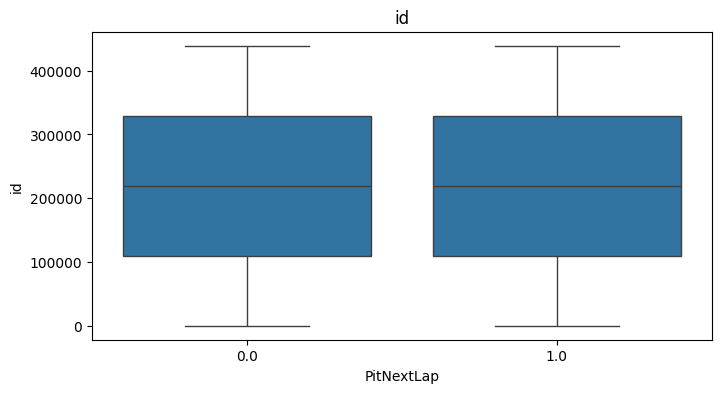

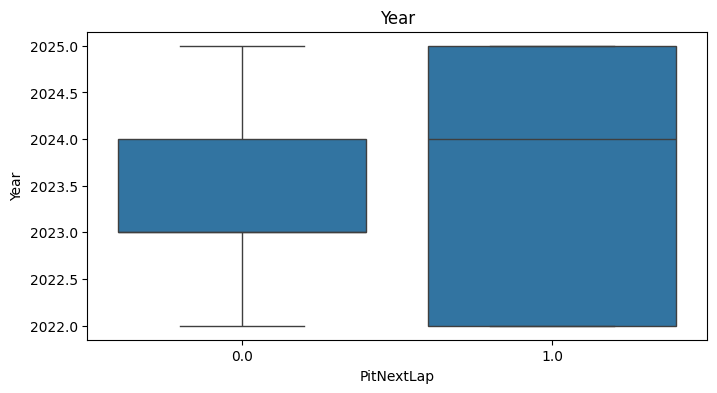

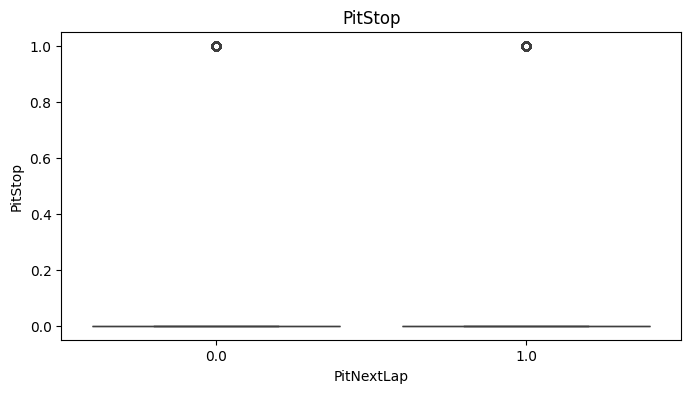

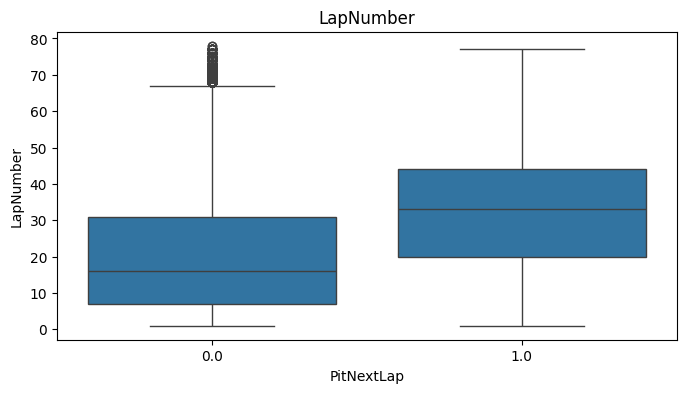

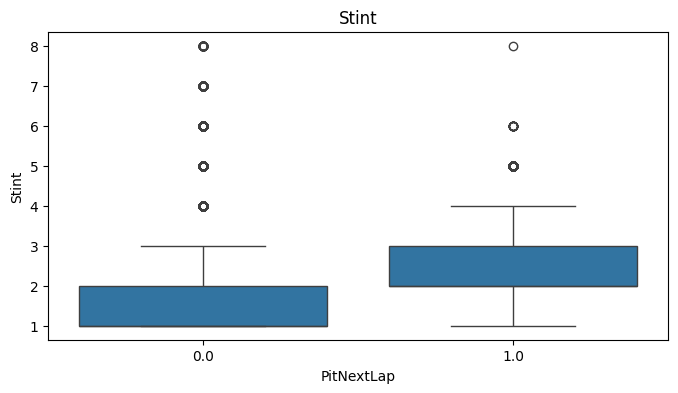

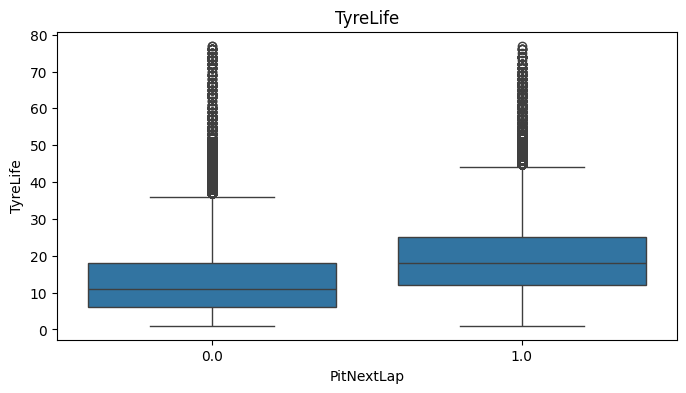

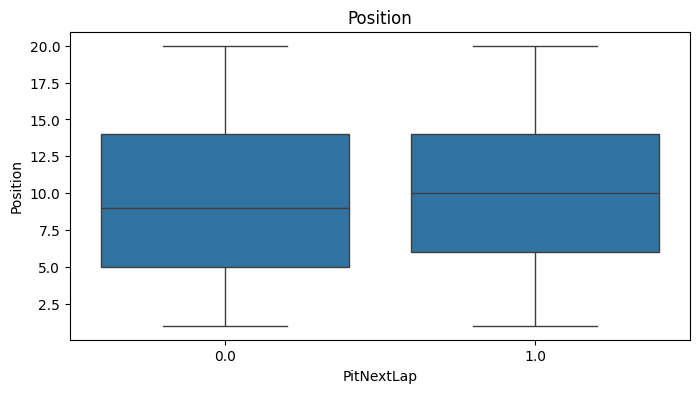

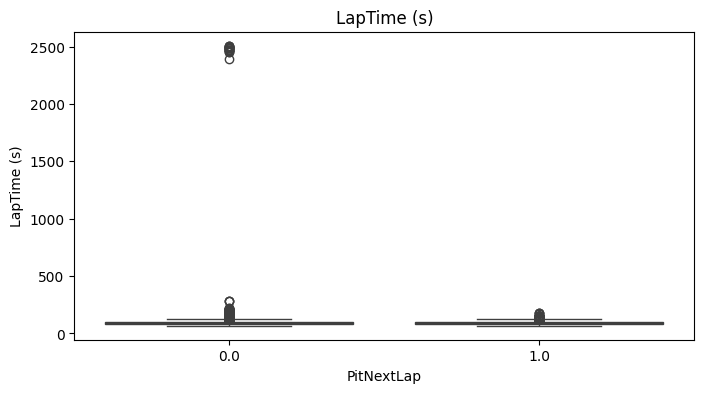

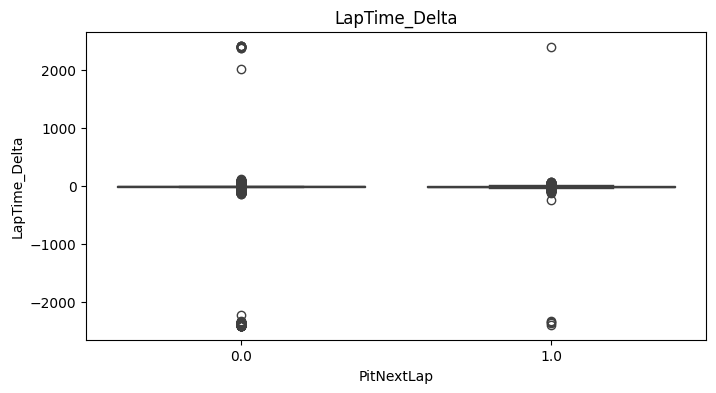

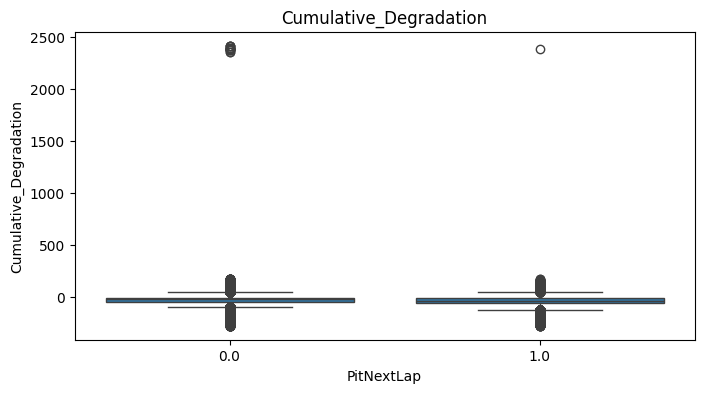

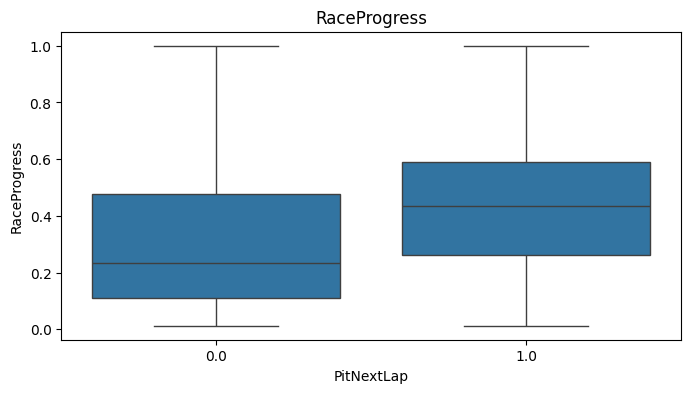

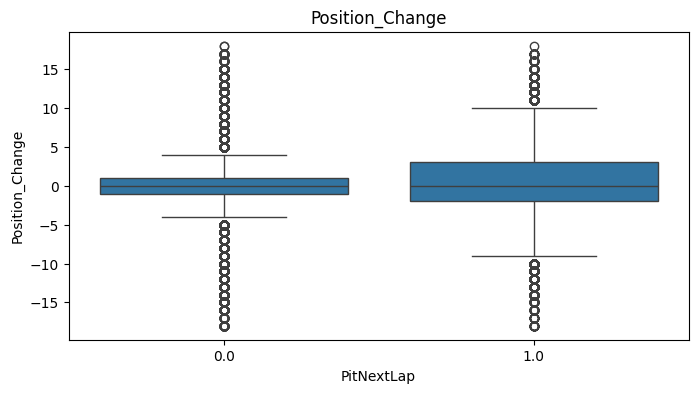

In [146]:
for col in train.select_dtypes(include='number').columns:
    if col != 'PitNextLap':
        plt.figure(figsize=(8,4))
        sns.boxplot(x='PitNextLap', y=col, data=train)
        plt.title(col)
        plt.show()

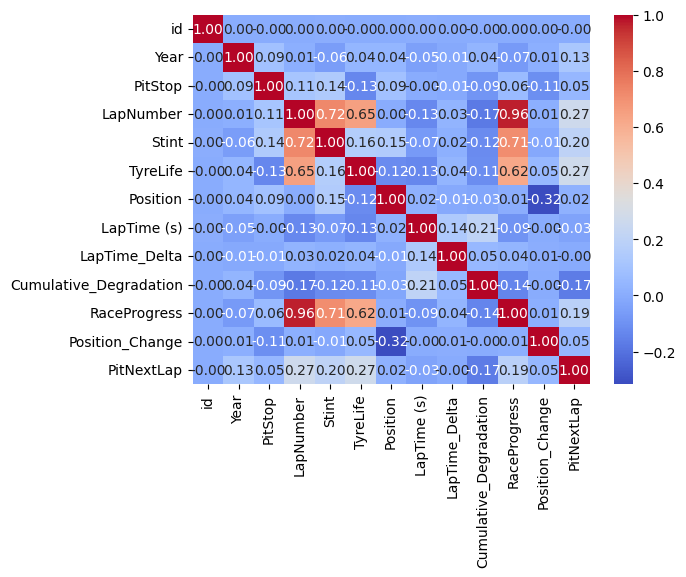

In [147]:
sns.heatmap(train.corr(numeric_only=True), 
            annot=True, fmt='.2f', 
            cmap='coolwarm')
plt.show()

#### Key Insights from EDA

1) The shape of training data is (439140, 16) and the shape of test data is (188165, 15) and data consists of 3 categorical columns and 11 numerical columns.
2) The target variable is PitNext lap in which 0 means the F1 car won't pit in the next lap and 1 means the F1 car will pit in the next lap. By target distribution we can see 0 is a little more than 3 times of 1.
3) In Compound column there are 5 unique values. In hard 0 is double of 1 and shows medium pit rate, In Medium, 0 is a lot more (roughly 8 times of 1) and shows the highest pit rate, In Intermediate, Soft and Wet the pit rate is very less or negligible.
4) In Race column, there are 26 unique values and all of them follow a similar pattern where 0 is much greater than 1.
5) In Year column 1 shows variation of 3 years but 0 shows variation of only 1 year.
6) The columns LapNumber, Stint, TyreLife, RaceProgress all follow a same patter where both 0 and 1 have same variation but 1 has a little higher values than 0.
7) The Strong numerical features: Year, LapNumber, Stint, TyreLife, RaceProgress
8) The Weak numerical features: PitStop, LapTime, LapTime_Delta, Cumulative_Degradation, Position, Position_Change
9) Two most correlated features are LapNumber and RaceProgress, LapNumber and Stint.

### Feature Engineering

In [5]:
# Finds the degradation by dividing life of tyre by stint
train['DegradationByStint'] = train['TyreLife'] / (train['Stint'] + 1)
test['DegradationByStint'] = test['TyreLife'] / (test['Stint'] + 1)

# Finds progress of lap by dividing life of tyre by lapnumber
train['LapProgress'] = train['TyreLife'] / (train['LapNumber'] + 1)
test['LapProgress'] = test['TyreLife'] / (test['LapNumber'] + 1)

# Tells the life of tyre in previous lap
train['TyreLife_lag1'] = train.groupby(['Driver', 'Race'])['TyreLife'].shift(1)
test['TyreLife_lag1'] = test.groupby(['Driver', 'Race'])['TyreLife'].shift(1)

# Tells how much the tyre degraded in the previous lap
train['TyreLife_diff'] = train['TyreLife'] - train['TyreLife_lag1']
test['TyreLife_diff'] = test['TyreLife'] - test['TyreLife_lag1']

# Tells the pit probability of specific driver
driver_pit_rate = train.groupby('Driver')['PitNextLap'].mean()
train['driver_encoded'] = train['Driver'].map(driver_pit_rate)
test['driver_encoded'] = test['Driver'].map(driver_pit_rate)

# Tells how often drivers pit in specific race track 
race_pit_rate = train.groupby('Race')['PitNextLap'].mean()
train['race_encoded'] = train['Race'].map(race_pit_rate)
test['race_encoded'] = test['Race'].map(race_pit_rate)

# Tells pit probability for each tyre compound
compound_pit_rate = train.groupby('Compound')['PitNextLap'].mean()
train['compound_encoded'] = train['Compound'].map(compound_pit_rate)
test['compound_encoded'] = test['Compound'].map(compound_pit_rate)

In [6]:
train['TyreLife_lag1'] = train['TyreLife_lag1'].fillna(0)
train['TyreLife_diff'] = train['TyreLife_diff'].fillna(0)
test['TyreLife_lag1'] = test['TyreLife_lag1'].fillna(0)
test['TyreLife_diff'] = test['TyreLife_diff'].fillna(0)

In [7]:
print(f'Training Data null values: {train.isnull().sum()}')
print(f'Test Data null values: {test.isnull().sum()}')

Training Data null values: id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
DegradationByStint        0
LapProgress               0
TyreLife_lag1             0
TyreLife_diff             0
driver_encoded            0
race_encoded              0
compound_encoded          0
dtype: int64
Test Data null values: id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)  

In [8]:
train = train.drop(columns='id')
test = test.drop(columns='id')

### Label Encoding

In [13]:
cat_cols = train.select_dtypes(include='object').columns.tolist()

C:\Users\LEGION\AppData\Local\Temp\ipykernel_19784\3149979814.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include='object').columns.tolist()


In [14]:
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))
    train[col] = le.transform(train[col])
    test[col] = le.transform(test[col])
    le_dict[col] = le

### Model Selection and Training

In [15]:
X = train.drop(columns=['PitNextLap'])
y = train['PitNextLap']
y = y.astype(int)

cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [16]:
print(y.dtype)
print(y.unique())

int64
[1 0]


In [17]:
scale_pos_weight = (train['PitNextLap'] == 0).sum() / (train['PitNextLap'] == 1).sum()

In [1]:
def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'num_leaves': trial.suggest_int('num_leaves', 31, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
    }

    model = LGBMClassifier(
        **params,
        scale_pos_weight=scale_pos_weight,
        verbose=-1,
        n_jobs=-1,
        random_state=42
    )

    score = cross_val_score(
        model, X, y,
        cv=cv,
        scoring='roc_auc',
        n_jobs=1
    ).mean()

    return score

study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=30, n_jobs=1)

print(f"Best Score: {study.best_value:.4f}")
print(f"Best Params: {study.best_params}")

In [ ]:
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 400, 1000),
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 8),
        'random_seed': 42,
        'verbose': 0,
        'thread_count': -1,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC'
    }
    
    model = CatBoostClassifier(**params)
    
    score = cross_val_score(
        model, X, y,
        cv=cv,
        scoring='roc_auc',
        n_jobs=1
    ).mean()
    
    return score


# Recommended settings for your laptop
study_cat = optuna.create_study(direction='maximize')

study_cat.optimize(
    objective_cat, 
    n_trials=25,      # Reduced from 30
    n_jobs=1,         # Keep this as 1 (safest)
    show_progress_bar=True
)

print(f"Best Score: {study_cat.best_value:.5f}")
print(f"Best Params: {study_cat.best_params}")

In [20]:
# Best params found via Optuna tuning
# Run Optuna cell above to retune if needed

lgbm_params = {'n_estimators': 595, 
               'max_depth': 11, 
               'num_leaves': 119, 
               'learning_rate': 0.05091626649646906, 
               'subsample': 0.8204110104389144, 
               'colsample_bytree': 0.6421265482834498, 
               'min_child_samples': 36}

cat_params = {'iterations': 823, 
              'depth': 8, 
              'learning_rate': 0.07197382519608132, 
              'l2_leaf_reg': 5.702894146844978}

xg_params = {'n_estimators': 800,
            'max_depth': 6,
            'learning_rate': 0.05,
            'subsample': 0.85,
            'colsample_bytree': 0.8,
            'min_child_weight': 5,
            'gamma': 0.1}

In [21]:
lgbm = LGBMClassifier(
    **lgbm_params,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    verbose=-1,
    random_state=42
)

cat = CatBoostClassifier(
    **cat_params,
    scale_pos_weight=scale_pos_weight,
    # n_jobs=-1,
    # verbose=-1,
    random_state=42
)

xgb_model = XGBClassifier(
    **xg_params,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    tree_method='hist'
)


### Checking Ensemble Model CV

In [22]:
xgb_cv = cross_val_predict(xgb_model, X, y, cv=cv, method='predict_proba')[:, 1]
lgbm_cv = cross_val_predict(lgbm, X, y, cv=cv, method='predict_proba')[:, 1]
cat_cv = cross_val_predict(cat, X, y, cv=cv, method='predict_proba')[:, 1]

ensemble_cv = (0.5*lgbm_cv + 0.35*cat_cv + 0.15*xgb_cv) / 3
print(f"Ensemble CV AUC: {roc_auc_score(y, ensemble_cv):.4f}")

0:	learn: 0.6355390	total: 219ms	remaining: 2m 59s
1:	learn: 0.5840592	total: 273ms	remaining: 1m 52s
2:	learn: 0.5419080	total: 321ms	remaining: 1m 27s
3:	learn: 0.5078626	total: 363ms	remaining: 1m 14s
4:	learn: 0.4805633	total: 403ms	remaining: 1m 5s
5:	learn: 0.4576420	total: 441ms	remaining: 1m
6:	learn: 0.4387435	total: 486ms	remaining: 56.6s
7:	learn: 0.4223479	total: 521ms	remaining: 53.1s
8:	learn: 0.4086347	total: 557ms	remaining: 50.4s
9:	learn: 0.3979300	total: 593ms	remaining: 48.2s
10:	learn: 0.3893405	total: 630ms	remaining: 46.5s
11:	learn: 0.3816806	total: 667ms	remaining: 45.1s
12:	learn: 0.3751065	total: 708ms	remaining: 44.1s
13:	learn: 0.3685251	total: 744ms	remaining: 43s
14:	learn: 0.3627173	total: 781ms	remaining: 42.1s
15:	learn: 0.3583089	total: 818ms	remaining: 41.2s
16:	learn: 0.3548070	total: 857ms	remaining: 40.6s
17:	learn: 0.3518259	total: 898ms	remaining: 40.2s
18:	learn: 0.3486969	total: 939ms	remaining: 39.7s
19:	learn: 0.3456406	total: 980ms	remainin

### Fitting, Predicting and Submitting file

In [ ]:
lgbm.fit(X, y)
cat.fit(X, y)
xgb_model.fit(X, y)

0:	learn: 0.6350877	total: 201ms	remaining: 2m 45s
1:	learn: 0.5833980	total: 257ms	remaining: 1m 45s
2:	learn: 0.5413107	total: 297ms	remaining: 1m 21s
3:	learn: 0.5071025	total: 334ms	remaining: 1m 8s
4:	learn: 0.4796625	total: 373ms	remaining: 1m 1s
5:	learn: 0.4567566	total: 412ms	remaining: 56.2s
6:	learn: 0.4378785	total: 455ms	remaining: 53.1s
7:	learn: 0.4213660	total: 494ms	remaining: 50.4s
8:	learn: 0.4078741	total: 532ms	remaining: 48.1s
9:	learn: 0.3972276	total: 571ms	remaining: 46.4s
10:	learn: 0.3879626	total: 609ms	remaining: 45s
11:	learn: 0.3805794	total: 649ms	remaining: 43.9s
12:	learn: 0.3741501	total: 688ms	remaining: 42.9s
13:	learn: 0.3689633	total: 726ms	remaining: 41.9s
14:	learn: 0.3642553	total: 764ms	remaining: 41.2s
15:	learn: 0.3594273	total: 800ms	remaining: 40.4s
16:	learn: 0.3553371	total: 841ms	remaining: 39.9s
17:	learn: 0.3521634	total: 880ms	remaining: 39.4s
18:	learn: 0.3492225	total: 919ms	remaining: 38.9s
19:	learn: 0.3460117	total: 958ms	remain

In [ ]:
xgb_preds  = xgb_model.predict_proba(test)[:, 1]
lgbm_preds = lgbm.predict_proba(test)[:, 1]
cat_preds  = cat.predict_proba(test)[:, 1]

In [52]:
final_preds = (
    0.55*cat_preds + 0.3*lgbm_preds + 0.15*xgb_preds   
)

In [53]:
data = {'id': test_ids, 'PitNextlap': final_preds}
submission_file = pd.DataFrame(data)
submission_file.to_csv('ensemble_cat_light_xg.csv', index=False)

### Results and Learnings

1) My best model was ensemble of catboost, lightgbm and xgboost and I got a score of 0.94911 in competition by it.
2) My biggest mistake was I added too many features which led to a drop in accuracy and score so I found importance of features and dropped all the useless features.
3) Next I would try more tuning in weight of each model in predicting by ensemble and using more better features.
4) I learned ensemble learning by using 3 strong models.
